In [210]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#STEP 1

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [212]:
df = pd.read_csv("/content/drive/MyDrive/ICT/heart_disease.csv")

In [213]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [214]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1025
Number of columns: 14


In [215]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [216]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [218]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [219]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64


In [220]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [221]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [222]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(col, ":", len(outliers), "outliers")

age : 0 outliers
sex : 0 outliers
cp : 0 outliers
trestbps : 30 outliers
chol : 16 outliers
fbs : 153 outliers
restecg : 0 outliers
thalach : 4 outliers
exang : 0 outliers
oldpeak : 7 outliers
slope : 0 outliers
ca : 87 outliers
thal : 7 outliers
target : 0 outliers


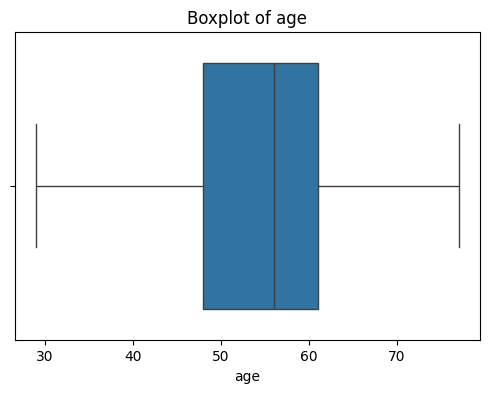

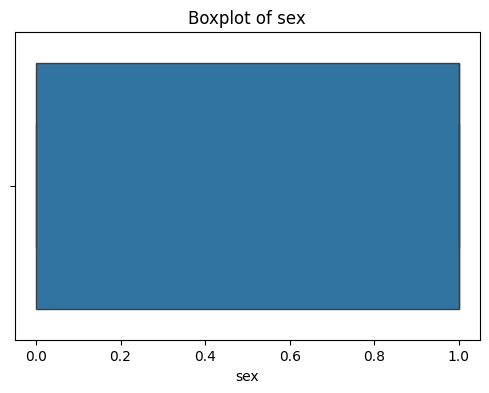

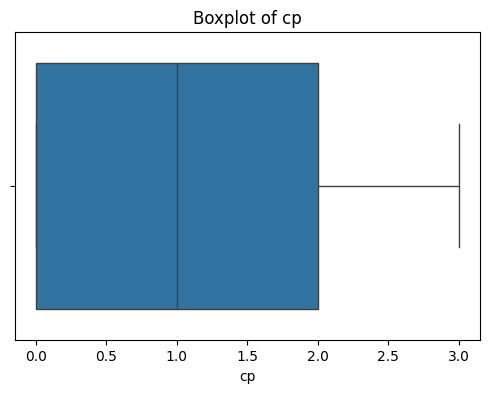

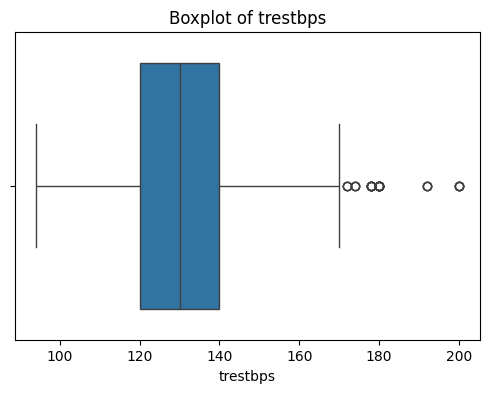

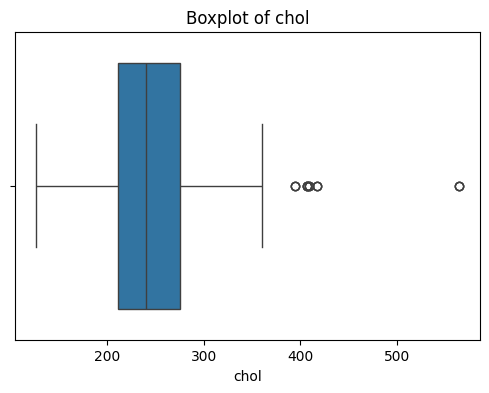

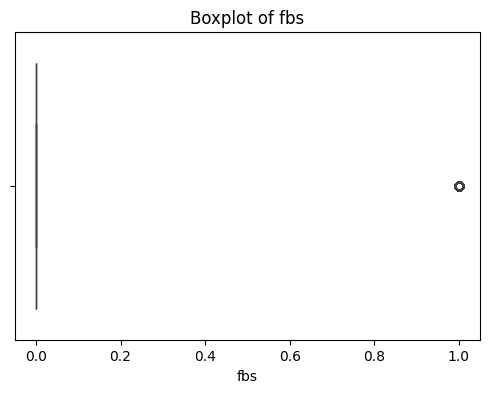

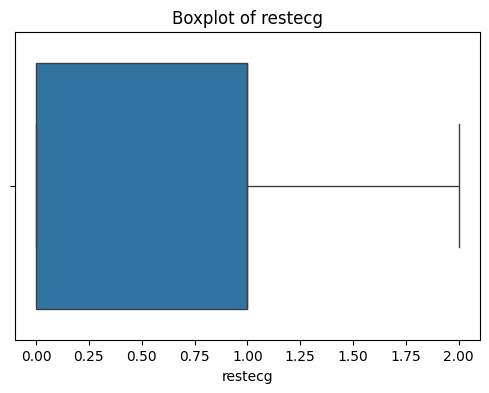

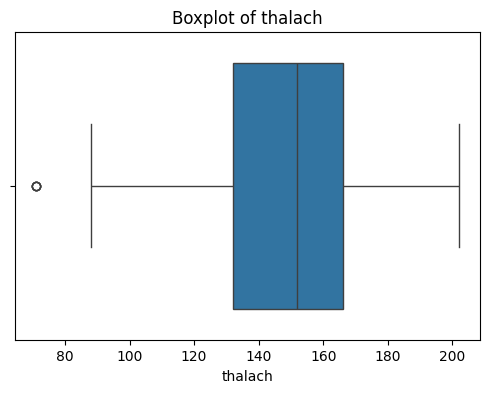

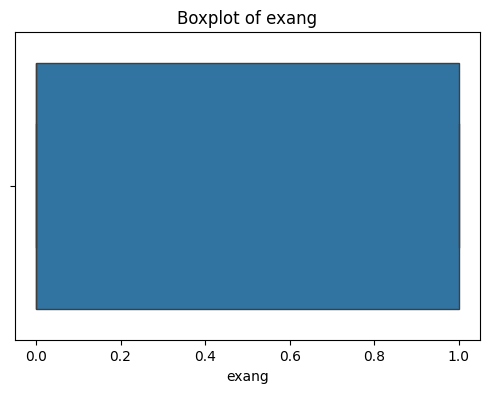

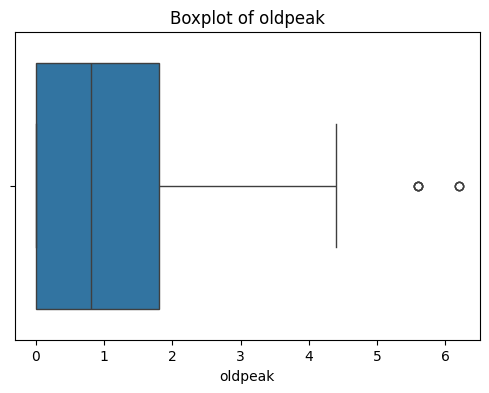

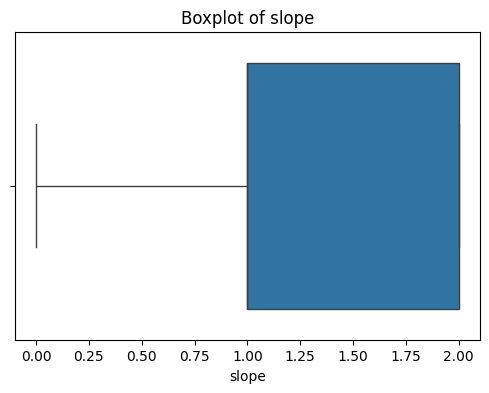

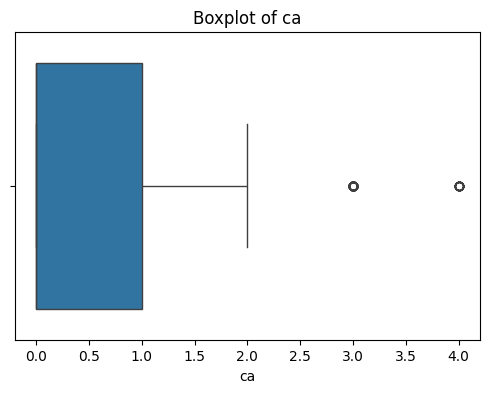

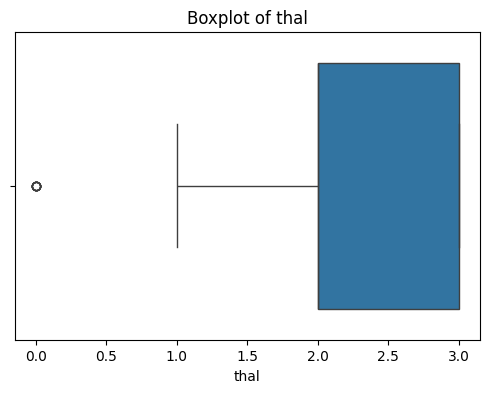

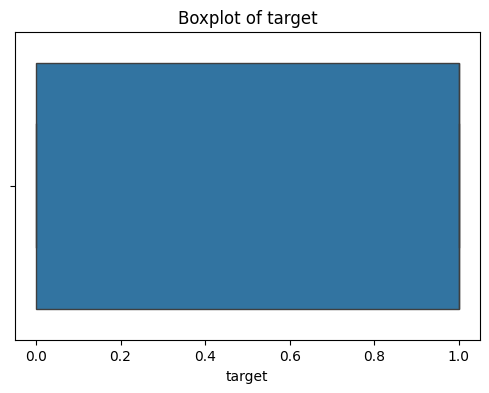

In [223]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [224]:
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

print(categorical_columns)

Index([], dtype='object')


In [225]:
categorical_columns = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal',
    'target'
]

In [226]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [227]:
categorical_columns = ['sex', 'cp', 'fbs', 'restecg',
                       'exang', 'slope', 'ca', 'thal', 'target']

for col in categorical_columns:
    if col in df.columns:
        print("\n", col)
        print(df[col].value_counts())


 sex
sex
1    713
0    312
Name: count, dtype: int64

 cp
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64

 fbs
fbs
0    872
1    153
Name: count, dtype: int64

 restecg
restecg
1    513
0    497
2     15
Name: count, dtype: int64

 exang
exang
0    680
1    345
Name: count, dtype: int64

 slope
slope
1    482
2    469
0     74
Name: count, dtype: int64

 ca
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

 thal
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64

 target
target
1    526
0    499
Name: count, dtype: int64


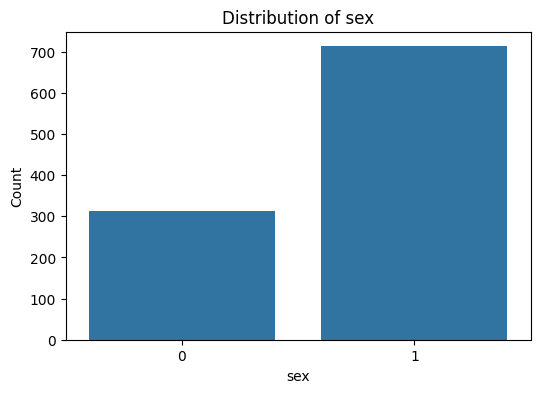

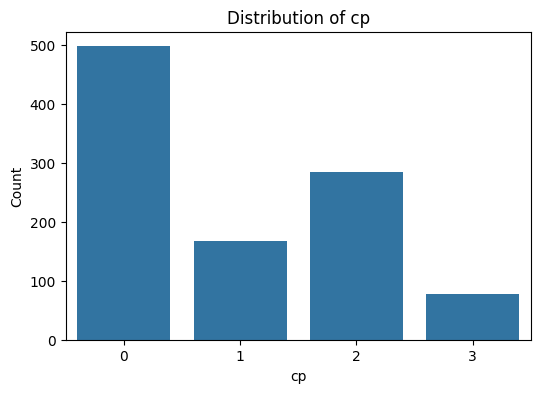

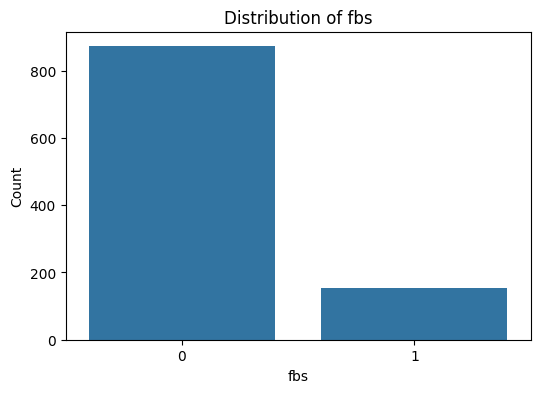

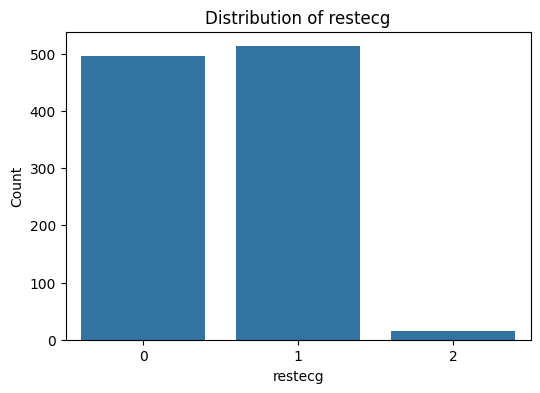

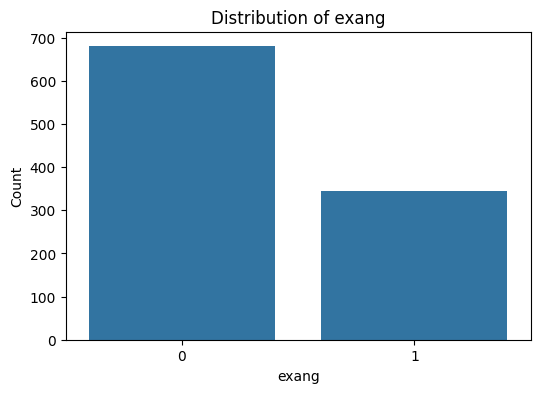

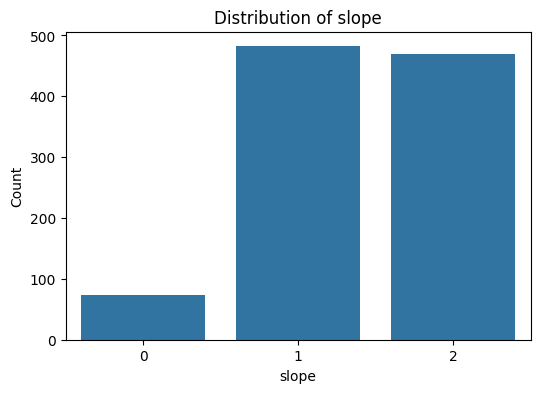

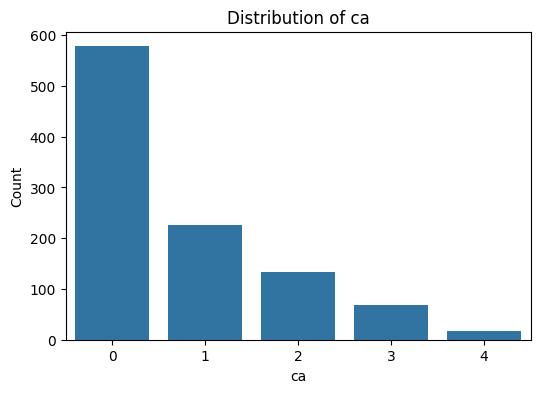

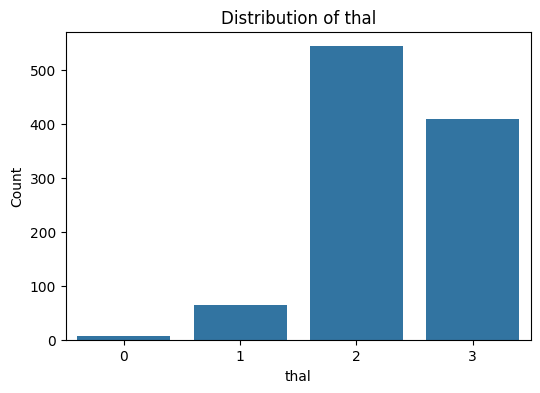

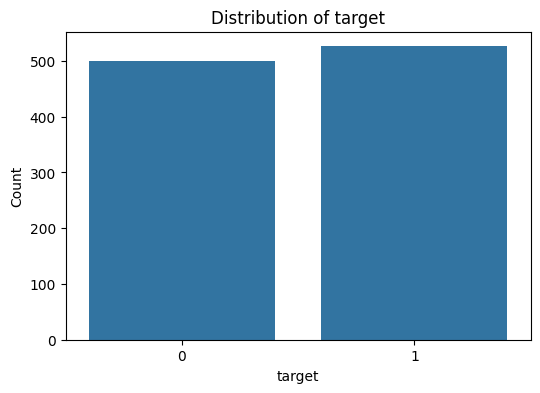

In [228]:
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

#STEP 2

In [229]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [230]:
numerical_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [231]:
categorical_columns = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [232]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [233]:
numerical_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(col, ":", len(outliers), "outliers")

age : 0 outliers
trestbps : 30 outliers
chol : 16 outliers
thalach : 4 outliers
oldpeak : 7 outliers


In [234]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower_bound,
        upper_bound
    )

In [235]:
df = pd.get_dummies(
    df,
    columns=['cp', 'restecg', 'thal'],
    drop_first=True,
    dtype=int
)

df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,0,0,0,0,1,0,0,0,1
1,53,1,140,203,1,155,1,3.1,0,0,0,0,0,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2.6,0,0,0,0,0,0,1,0,0,0,1
3,61,1,148,203,0,161,0,0.0,2,1,0,0,0,0,1,0,0,0,1
4,62,0,138,294,1,106,0,1.9,1,3,0,0,0,0,1,0,0,1,0


In [236]:
df['sex'] = df['sex'].astype(int)
df['fbs'] = df['fbs'].astype(int)

print("Sex values:", df['sex'].unique())
print("FBS values:", df['fbs'].unique())

Sex values: [1 0]
FBS values: [0 1]


In [272]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData:")
df.head()

Shape: (1025, 19)

Missing values:
age          0
sex          0
trestbps     0
chol         0
fbs          0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
target       0
cp_1         0
cp_2         0
cp_3         0
restecg_1    0
restecg_2    0
thal_1       0
thal_2       0
thal_3       0
dtype: int64

Data:


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,-0.378869,-0.691104,0,0.824084,0,-0.054537,2,2,0,0,0,0,1,0,0,0,1
1,53,1,0.528894,-0.879693,1,0.255654,1,1.785457,0,0,0,0,0,0,0,0,0,0,1
2,70,1,0.831481,-1.487368,0,-1.056105,1,1.347363,0,0,0,0,0,0,1,0,0,0,1
3,61,1,1.013034,-0.879693,0,0.518006,0,-0.930725,2,1,0,0,0,0,1,0,0,0,1
4,62,0,0.407859,1.027150,1,-1.886886,0,0.734031,1,3,0,0,0,0,1,0,0,1,0


In [273]:
scaler = StandardScaler()

In [274]:
scale_columns = [
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

df[scale_columns] = scaler.fit_transform(df[scale_columns])

In [239]:
df[scale_columns].head()

,trestbps,chol,thalach,oldpeak
0,-0.378869,-0.691104,0.824084,-0.054537
1,0.528894,-0.879693,0.255654,1.785457
2,0.831481,-1.487368,-1.056105,1.347363
3,1.013034,-0.879693,0.518006,-0.930725
4,0.407859,1.027150,-1.886886,0.734031


#STEP 3

In [241]:
X_reg = df.drop(columns=['chol'])
y_reg = df['chol']

In [242]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [243]:
print("Regression Training Features:", X_train_reg.shape)
print("Regression Testing Features:", X_test_reg.shape)

print("Regression Training Target:", y_train_reg.shape)
print("Regression Testing Target:", y_test_reg.shape)

Regression Training Features: (820, 18)
Regression Testing Features: (205, 18)
Regression Training Target: (820,)
Regression Testing Target: (205,)


In [244]:
X_cls = df.drop(columns=['target'])
y_cls = df['target']

In [245]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

In [246]:
print("Classification Training Features:", X_train_cls.shape)
print("Classification Testing Features:", X_test_cls.shape)

print("Classification Training Target:", y_train_cls.shape)
print("Classification Testing Target:", y_test_cls.shape)

Classification Training Features: (820, 18)
Classification Testing Features: (205, 18)
Classification Training Target: (820,)
Classification Testing Target: (205,)


In [247]:

print("Regression:")
print("X_train:", X_train_reg.shape)
print("X_test :", X_test_reg.shape)

print("\nClassification:")
print("X_train:", X_train_cls.shape)
print("X_test :", X_test_cls.shape)

Regression:
X_train: (820, 18)
X_test : (205, 18)

Classification:
X_train: (820, 18)
X_test : (205, 18)


#STEP *3*

In [248]:
linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

y_pred_linear = linear_model.predict(X_test_reg)

In [249]:
svm_model = SVR()

svm_model.fit(X_train_reg, y_train_reg)

y_pred_svm = svm_model.predict(X_test_reg)

In [250]:
rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg_model.fit(X_train_reg, y_train_reg)

y_pred_rf_reg = rf_reg_model.predict(X_test_reg)

In [251]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_cls, y_train_cls)

y_pred_logistic = logistic_model.predict(X_test_cls)

In [252]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_cls, y_train_cls)

y_pred_knn = knn_model.predict(X_test_cls)

In [253]:
rf_cls_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_cls_model.fit(X_train_cls, y_train_cls)

y_pred_rf_cls = rf_cls_model.predict(X_test_cls)

#STEP *4*

In [283]:
linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)



LinearRegression()

In [ ]:
y_pred_linear = linear_model.predict(X_test_reg)


In [277]:
svm_model = SVR()

svm_model.fit(X_train_reg, y_train_reg)

y_pred_svm = svm_model.predict(X_test_reg)

In [278]:
rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg_model.fit(X_train_reg, y_train_reg)

y_pred_rf_reg = rf_reg_model.predict(X_test_reg)

In [279]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_cls, y_train_cls)

y_pred_logistic = logistic_model.predict(X_test_cls)

In [280]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_cls, y_train_cls)

y_pred_knn = knn_model.predict(X_test_cls)

In [281]:
rf_cls_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_cls_model.fit(X_train_cls, y_train_cls)

y_pred_rf_cls = rf_cls_model.predict(X_test_cls)

#STEP *5*

In [260]:
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)

print("Linear Regression MAE:", mae_linear)

Linear Regression MAE: 0.7935053018989049


In [261]:
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)

print("Linear Regression MSE:", mse_linear)

Linear Regression MSE: 1.0071831374768538


In [262]:
r2_linear = r2_score(y_test_reg, y_pred_linear)

print("Linear Regression R²:", r2_linear)

Linear Regression R²: 0.051953735725618455


In [263]:
for name, predictions in [
    ("Linear Regression", y_pred_linear),
    ("SVM", y_pred_svm),
    ("Random Forest", y_pred_rf_reg)
]:
    print("\n", name)
    print("MAE:", mean_absolute_error(y_test_reg, predictions))
    print("MSE:", mean_squared_error(y_test_reg, predictions))
    print("R²:", r2_score(y_test_reg, predictions))


 Linear Regression
MAE: 0.7935053018989049
MSE: 1.0071831374768538
R²: 0.051953735725618455

 SVM
MAE: 0.8177635203356489
MSE: 1.0502768012554988
R²: 0.011390321348380028

 Random Forest
MAE: 0.17487756702078294
MSE: 0.07362466214371476
R²: 0.9306982183213762


In [264]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test_cls, y_pred_logistic))
print("Precision:", precision_score(y_test_cls, y_pred_logistic))
print("Recall:", recall_score(y_test_cls, y_pred_logistic))
print("F1-Score:", f1_score(y_test_cls, y_pred_logistic))

Logistic Regression
Accuracy: 0.848780487804878
Precision: 0.8135593220338984
Recall: 0.9142857142857143
F1-Score: 0.8609865470852018


In [265]:
print("KNN")

print("Accuracy:", accuracy_score(y_test_cls, y_pred_knn))
print("Precision:", precision_score(y_test_cls, y_pred_knn))
print("Recall:", recall_score(y_test_cls, y_pred_knn))
print("F1-Score:", f1_score(y_test_cls, y_pred_knn))

KNN
Accuracy: 0.8390243902439024
Precision: 0.8529411764705882
Recall: 0.8285714285714286
F1-Score: 0.8405797101449275


In [266]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test_cls, y_pred_rf_cls))
print("Precision:", precision_score(y_test_cls, y_pred_rf_cls))
print("Recall:", recall_score(y_test_cls, y_pred_rf_cls))
print("F1-Score:", f1_score(y_test_cls, y_pred_rf_cls))

Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


#STEP 6

In [267]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVM',
        'Random Forest'
    ],
    'MAE': [
        mean_absolute_error(y_test_reg, y_pred_linear),
        mean_absolute_error(y_test_reg, y_pred_svm),
        mean_absolute_error(y_test_reg, y_pred_rf_reg)
    ],
    'MSE': [
        mean_squared_error(y_test_reg, y_pred_linear),
        mean_squared_error(y_test_reg, y_pred_svm),
        mean_squared_error(y_test_reg, y_pred_rf_reg)
    ],
    'R²': [
        r2_score(y_test_reg, y_pred_linear),
        r2_score(y_test_reg, y_pred_svm),
        r2_score(y_test_reg, y_pred_rf_reg)
    ]
})

regression_results

,Model,MAE,MSE,R²
0,Linear Regression,0.793505,1.007183,0.051954
1,SVM,0.817764,1.050277,0.011390
2,Random Forest,0.174878,0.073625,0.930698


In [268]:
best_regression = regression_results.loc[
    regression_results['R²'].idxmax()
]

print("Best Regression Model:", best_regression['Model'])
print("R² Score:", best_regression['R²'])

Best Regression Model: Random Forest
R² Score: 0.9306982183213762


In [269]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test_cls, y_pred_logistic),
        accuracy_score(y_test_cls, y_pred_knn),
        accuracy_score(y_test_cls, y_pred_rf_cls)
    ],
    'Precision': [
        precision_score(y_test_cls, y_pred_logistic),
        precision_score(y_test_cls, y_pred_knn),
        precision_score(y_test_cls, y_pred_rf_cls)
    ],
    'Recall': [
        recall_score(y_test_cls, y_pred_logistic),
        recall_score(y_test_cls, y_pred_knn),
        recall_score(y_test_cls, y_pred_rf_cls)
    ],
    'F1-Score': [
        f1_score(y_test_cls, y_pred_logistic),
        f1_score(y_test_cls, y_pred_knn),
        f1_score(y_test_cls, y_pred_rf_cls)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.848780,0.813559,0.914286,0.860987
1,KNN,0.839024,0.852941,0.828571,0.840580
2,Random Forest,1.000000,1.000000,1.000000,1.000000


In [270]:
best_classification = classification_results.loc[
    classification_results['Recall'].idxmax()
]

print("Best Classification Model:", best_classification['Model'])
print("Recall:", best_classification['Recall'])

Best Classification Model: Random Forest
Recall: 1.0


In [271]:
print("===== REGRESSION RESULTS =====")
display(regression_results)

print("\nBest Regression Model:",
      best_regression['Model'])

print("\n===== CLASSIFICATION RESULTS =====")
display(classification_results)

print("\nBest Classification Model:",
      best_classification['Model'])

===== REGRESSION RESULTS =====


,Model,MAE,MSE,R²
0,Linear Regression,0.793505,1.007183,0.051954
1,SVM,0.817764,1.050277,0.011390
2,Random Forest,0.174878,0.073625,0.930698



Best Regression Model: Random Forest

===== CLASSIFICATION RESULTS =====


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.848780,0.813559,0.914286,0.860987
1,KNN,0.839024,0.852941,0.828571,0.840580
2,Random Forest,1.000000,1.000000,1.000000,1.000000



Best Classification Model: Random Forest
